In [1]:
import os
import cv2
import imagehash
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

# -------------------------
# Config
# -------------------------
DATA_ROOT = "../data"
TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train_data")
TRAIN_MSK_DIR = os.path.join(DATA_ROOT, "train_data")

PATCH_SIZE = 384
N_PATCHES = 10                  # patches per slide

MARGIN = 16                     # bbox margin (optional use later)

MASK_PATCH_FRAC = 0.75          # fraction of patches that should be mask-driven
MIN_MASK_PIXELS_SLIDE = 50      # if slide mask has fewer pixels -> treat as "no mask"
MIN_MASK_IN_PATCH = 30          # mask pixels required in a "mask" patch
MIN_TISSUE_FRAC = 0.07          # tissue fraction required to accept a patch

MIN_CENTER_DIST = PATCH_SIZE // 2
MAX_TRIES_PER_SLIDE = 10      # hard cap to prevent infinite loops
MAX_TRIES_PER_PATCH = 5        # local tries before relaxing constraints


OUT_DIR = os.path.join("processed", "numpy_patches")
os.makedirs(OUT_DIR, exist_ok=True)

# class mapping
CLASS2ID: dict[str, int] = {"Luminal A": 0, "Luminal B": 1, "HER2(+)": 2, "Triple negative": 3}
ID2CLASS: dict[int, str] = {0:"Luminal A", 1:"Luminal B", 2:"HER2(+)", 3:"Triple negative"}

# assertions
assert os.path.exists(TRAIN_IMG_DIR), f"Train image dir not found: {TRAIN_IMG_DIR}"
assert os.path.exists(TRAIN_MSK_DIR), f"Train mask dir not found: {TRAIN_MSK_DIR}"
for key, val in CLASS2ID.items():
    assert ID2CLASS[val] == key, "CLASS2ID and ID2CLASS mismatch for class " + key

In [2]:
# -------------------------
# DataFrame cleanup
# -------------------------
def cleanup_train_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove entries from df where the corresponding image file does not exist.
    :param df: DataFrame with at least a "sample_index" column
    :return: Cleaned DataFrame
    """
    to_drop = []
    for idx, row in df.iterrows():
        sample_index = row["sample_index"]
        img_path = os.path.join(TRAIN_IMG_DIR, sample_index)
        if not os.path.exists(img_path):
            to_drop.append(idx)
    df = df.drop(to_drop).reset_index(drop=True)
    return df

In [3]:
# -------------------------
# IO helpers
# -------------------------
def read_rgb(path: str) -> np.ndarray:
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def read_mask(path: str) -> np.ndarray:
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(path)
    return (m > 0).astype(np.uint8)


# -------------------------
# Geometry helpers
# -------------------------
def clamp_center(cx, cy, w, h, half):
    cx = int(np.clip(cx, half, w - half - 1))
    cy = int(np.clip(cy, half, h - half - 1))
    return cx, cy

def crop_patch(img, cx, cy, ps):
    half = ps // 2
    x0, x1 = cx - half, cx + half
    y0, y1 = cy - half, cy + half
    return img[y0:y1, x0:x1]

def far_enough(cx, cy, centers, min_dist_sq: int) -> bool:
    for x, y in centers:
        if (cx - x) * (cx - x) + (cy - y) * (cy - y) < min_dist_sq:
            return False
    return True

def box_from_center(cx, cy, half):
    return (cx-half, cy-half, cx+half, cy+half)

def iou(a, b):
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    ix0, iy0 = max(ax0, bx0), max(ay0, by0)
    ix1, iy1 = min(ax1, bx1), min(ay1, by1)
    iw, ih = max(0, ix1-ix0), max(0, iy1-iy0)
    inter = iw * ih
    if inter == 0: return 0.0
    area_a = (ax1-ax0) * (ay1-ay0)
    area_b = (bx1-bx0) * (by1-by0)
    return inter / (area_a + area_b - inter)

def too_much_overlap(new_box, boxes, max_iou=0.7):
    return any(iou(new_box, b) > max_iou for b in boxes)

# -------------------------
# Robust tissue detector (LAB distance from background)
# -------------------------
def tissue_mask_from_rgb_lab(rgb: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    h, w = lab.shape[:2]
    b = max(8, min(h, w) // 50)  # adaptive border thickness

    border = np.concatenate([
        lab[:b, :, :].reshape(-1, 3),
        lab[-b:, :, :].reshape(-1, 3),
        lab[:, :b, :].reshape(-1, 3),
        lab[:, -b:, :].reshape(-1, 3),
    ], axis=0)

    bg_mean = border.mean(axis=0)
    bg_std  = border.std(axis=0) + 1e-6

    d = ((lab - bg_mean) / bg_std) ** 2
    d = d.sum(axis=2)

    # robust threshold: keep top ~10% most "non-background" pixels
    thr = np.percentile(d, 90)
    t = (d > thr).astype(np.uint8)

    t = cv2.medianBlur(t, 5)
    kernel = np.ones((5, 5), np.uint8)
    t = cv2.morphologyEx(t, cv2.MORPH_CLOSE, kernel, iterations=1)
    return t

def tissue_fraction(rgb_patch: np.ndarray) -> float:
    return float(tissue_mask_from_rgb_lab(rgb_patch).mean())


# -------------------------
# Mask component sampling
# -------------------------
def get_mask_components(mask: np.ndarray):
    num, labels = cv2.connectedComponents(mask, connectivity=8)
    comps = []
    for k in range(1, num):
        ys, xs = np.where(labels == k)
        if len(xs) > 0:
            comps.append((xs, ys))
    return comps

def sample_from_components(components, rng: np.random.Generator):
    areas = np.array([len(c[0]) for c in components], dtype=np.float64)
    probs = areas / areas.sum()
    idx = rng.choice(len(components), p=probs)
    xs, ys = components[idx]
    j = rng.integers(0, len(xs))
    return int(xs[j]), int(ys[j])

def sample_from_binary(binmask: np.ndarray, rng: np.random.Generator):
    ys, xs = np.where(binmask > 0)
    if len(xs) == 0:
        return None
    j = rng.integers(0, len(xs))
    return int(xs[j]), int(ys[j])

# -------------------------
# Patch hashing (to avoid duplicates)
# -------------------------
def quick_patch_hash(rgb, size=32):
    # very cheap perceptual-ish hash
    small = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_AREA)
    return hash((small.mean(axis=2) > 128).astype(np.uint8).tobytes())

def ahash_u64(rgb_patch, hash_size=8):
    # grayscale + downsample to (hash_size x hash_size)
    gray = (0.299 * rgb_patch[...,0] + 0.587 * rgb_patch[...,1] + 0.114 * rgb_patch[...,2]).astype(np.float32)
    small = gray.reshape(hash_size, rgb_patch.shape[0]//hash_size, hash_size, rgb_patch.shape[1]//hash_size).mean(axis=(1,3))
    bits = small > small.mean()
    # pack into uint64
    h = 0
    for b in bits.flatten():
        h = (h << 1) | int(b)
    return h

def patch_key(patch_rgb, patch_msk, hash_size=16):
    """
    Compute combined hash key for RGB patch and mask patch.
    Returns a tuple of (imagehash for RGB, imagehash for mask).
    """
    # RGB hash
    h_img = imagehash.phash(Image.fromarray(patch_rgb), hash_size=hash_size)

    # Mask hash (squeeze + uint8)
    m = (patch_msk > 0).astype(np.uint8) * 255
    h_msk = imagehash.phash(Image.fromarray(m), hash_size=hash_size)

    return h_img, h_msk


In [4]:
def build_train_numpy(
    df,                         # DataFrame with columns: ["sample_index","label"]
    train_img_dir: str,
    train_msk_dir: str,
    out_dir: str,
    *,
    patch_size: int = 384,
    n_patches: int = 16,
    mask_patch_frac: float = 0.75,
    min_mask_pixels_slide: int = 50,
    min_mask_in_patch: int = 10,          # lowered to avoid deadlocks on tiny masks
    min_tissue_frac: float = 0.07,
    min_dist_tissue: int | None = None,   # default: patch_size//2
    min_dist_mask: int | None = None,     # default: patch_size//4
    max_tries_per_slide: int = 8000,
    max_tries_per_patch: int = 80,
    seed: int = 42,
    class2id: dict | None = None,
):
    """
    Build memmapped numpy patch dataset from slide-level train set.

    - Per slide: extracts `n_patches` patches (uint8 RGB) and associated mask patches (uint8 0/255).
    - Deterministic mask quota + guaranteed termination (hard cap + spill to tissue + optional padding).
    - Robust tissue filter using LAB distance from border-estimated background.

    Expected helpers available in your notebook/script:
      - read_rgb(path) -> (H,W,3) uint8 RGB
      - read_mask(path) -> (H,W) uint8 {0,1} or bool
      - crop_patch(img, cx, cy, patch_size)
      - clamp_center(cx, cy, w, h, half)
      - far_enough(cx, cy, centers, min_dist_sq)
      - get_mask_components(mask) -> list of (xs, ys) arrays for each component
      - sample_from_components(components, rng) -> (cx, cy)
      - sample_from_binary(binmask, rng) -> (cx, cy) or None
      - tissue_mask_from_rgb_lab(rgb) -> (H,W) uint8 {0,1}
      - tissue_fraction(rgb_patch) -> float in [0,1]
    """
    os.makedirs(out_dir, exist_ok=True)
    rng = np.random.default_rng(seed)

    if class2id is None:
        class2id = {"Luminal A": 0, "Luminal B": 1, "HER2(+)": 2, "Triple Negative": 3}

    slide_ids = df["sample_index"].tolist()
    y = df["label"].map(class2id).astype(int).to_numpy()

    n_slides = len(slide_ids)
    total_patches = n_slides * n_patches

    # distances
    if min_dist_tissue is None:
        min_dist_tissue = patch_size // 2
    if min_dist_mask is None:
        min_dist_mask = patch_size // 4

    min_dist_sq_tissue = int(min_dist_tissue * min_dist_tissue)
    min_dist_sq_mask = int(min_dist_mask * min_dist_mask)

    # outputs
    x_path = os.path.join(out_dir, f"train_x_uint8_{patch_size}.dat")
    m_path = os.path.join(out_dir, f"train_m_uint8_{patch_size}.dat")
    y_path = os.path.join(out_dir, "train_y_int64.npy")
    idx_path = os.path.join(out_dir, "train_slide_to_patchidx.npy")
    log_path = os.path.join(out_dir, "train_build_log.csv")

    X = np.memmap(x_path, dtype=np.uint8, mode="w+", shape=(total_patches, patch_size, patch_size, 3))
    M = np.memmap(m_path, dtype=np.uint8, mode="w+", shape=(total_patches, patch_size, patch_size, 1))
    slide_to_patchidx = np.zeros((n_slides, 2), dtype=np.int64)

    logs = []
    patch_ptr = 0

    for s, slide_id in tqdm(enumerate(slide_ids), desc="Building memmapped numpy patch dataset from slide-level train set", total=n_slides):
        img_path = os.path.join(train_img_dir, slide_id)
        msk_path = os.path.join(train_msk_dir, slide_id.replace("img", "mask"))

        rgb = read_rgb(img_path)
        msk = read_mask(msk_path).astype(np.uint8)
        if msk.mean() > 0.5:
            msk = 1 - msk

        h, w = rgb.shape[:2]
        half = patch_size // 2

        # Per-slide tissue mask (for tissue sampling)
        tmask = tissue_mask_from_rgb_lab(rgb)

        # Per-slide components
        mask_pixels_slide = int(msk.sum())
        components = get_mask_components(msk) if mask_pixels_slide >= min_mask_pixels_slide else []

        # ---- per-slide quotas (deterministic, but capped by feasibility) ----
        k_mask_target = int(round(n_patches * mask_patch_frac))

        # If mask is basically absent, don't insist on mask patches
        if len(components) == 0:
            k_mask_target = 0
        else:
            # Cap mask quota by "geometric capacity" to prevent deadlocks on tiny/fragmented masks
            # Very conservative: at most ~1 patch per component (you can relax later)
            MAX_PATCHES_PER_COMPONENT = 2
            k_mask_target = min(
                k_mask_target,
                MAX_PATCHES_PER_COMPONENT * len(components)
            )


        # ---- sampling state ----
        centers = []
        boxes = []
        seen_hashes = []
        MAX_DHASH_DIST = 3

        mask_done = 0
        tissue_done = 0
        produced = 0
        tries = 0

        start = patch_ptr

        # ---- sampling loop with hard cap ----
        while produced < n_patches and tries < max_tries_per_slide:
            tries += 1

            # insist on mask until quota met, then tissue
            use_mask = (mask_done < k_mask_target) and (len(components) > 0)

            # if we are stuck trying to satisfy mask quota, spill to tissue early
            if use_mask and tries > (max_tries_per_slide // 5):
                k_mask_target = mask_done
                use_mask = False

            for _ in range(max_tries_per_patch):
                # choose center
                if use_mask:
                    cx, cy = sample_from_components(components, rng)
                else:
                    c = sample_from_binary(tmask, rng)
                    if c is None:
                        cx = int(rng.integers(half, w - half))
                        cy = int(rng.integers(half, h - half))
                    else:
                        cx, cy = c

                cx, cy = clamp_center(cx, cy, w, h, half)

                # distance constraint (looser for mask)
                min_dist_sq_use = min_dist_sq_mask if use_mask else min_dist_sq_tissue
                if not far_enough(cx, cy, centers, min_dist_sq_use):
                    continue

                new_box = box_from_center(cx, cy, half)
                if too_much_overlap(new_box, boxes, max_iou=0.7):
                    continue

                patch_rgb = crop_patch(rgb, cx, cy, patch_size)
                patch_msk = crop_patch(msk, cx, cy, patch_size)

                if patch_rgb.shape[:2] != (patch_size, patch_size):
                    continue

                # reject low-tissue patches
                tmask_patch = crop_patch(tmask, cx, cy, patch_size)  # tmask is 0/1
                if tmask_patch.shape[:2] != (patch_size, patch_size):
                    continue
                tfrac = float(tmask_patch.mean())
                if tfrac < min_tissue_frac:
                    continue

                gray = patch_rgb.mean(axis=2)  # float
                if gray.std() < 5.0:           # tune: 3-10
                    continue


                # if this is a mask patch, require some mask presence
                mask_px = int((patch_msk > 0).sum())
                if use_mask and mask_px < min_mask_in_patch:
                    continue

                # if this is a mask patch, require some mask presence
                mask_px = int((patch_msk > 0).sum())
                if use_mask and mask_px < min_mask_in_patch:
                    continue

                # hard reject duplicates
                ph = imagehash.dhash(Image.fromarray(patch_rgb), hash_size=8)  # 8 => 64-bit hash
                # reject if too similar to any previously accepted patch in this slide
                if any((ph - h) <= MAX_DHASH_DIST for h in seen_hashes):
                    continue
                seen_hashes.append(ph)

                # accept
                centers.append((cx, cy))
                boxes.append(new_box)

                X[patch_ptr] = patch_rgb
                M[patch_ptr, :, :, 0] = (patch_msk > 0).astype(np.uint8) * 255

                patch_ptr += 1
                produced += 1
                if use_mask:
                    mask_done += 1
                else:
                    tissue_done += 1

                break

        end = patch_ptr
        slide_to_patchidx[s] = (start, end)

        status = "ok" if produced == n_patches else "partial"

        # If we couldn't fill, pad with last patch (keeps array shapes consistent)
        if produced < n_patches and produced > 0:
            last_rgb = X[patch_ptr - 1].copy()
            last_msk = M[patch_ptr - 1].copy()
            while produced < n_patches:
                X[patch_ptr] = last_rgb
                M[patch_ptr] = last_msk
                patch_ptr += 1
                produced += 1
            slide_to_patchidx[s] = (start, patch_ptr)
            status = "padded"
            end = patch_ptr

        if produced == 0:
            raise RuntimeError(
                f"Could not extract any patch for slide {slide_id}. "
                f"Try lowering min_tissue_frac/min_mask_in_patch or check tissue detector."
            )

        logs.append({
            "slide_id": slide_id,
            "produced": produced,
            "mask_done": mask_done,
            "tissue_done": tissue_done,
            "mask_pixels_slide": mask_pixels_slide,
            "n_components": len(components),
            "tries": tries,
            "status": status,
            "patch_range_start": int(start),
            "patch_range_end": int(end),
        })

    # Save metadata
    np.save(y_path, y.astype(np.int64))
    np.save(idx_path, slide_to_patchidx)
    pd.DataFrame(logs).to_csv(log_path, index=False)

    X.flush()
    M.flush()

    return {
        "x_path": x_path,
        "m_path": m_path,
        "y_path": y_path,
        "idx_path": idx_path,
        "log_path": log_path,
        "n_slides": n_slides,
        "total_patches": total_patches,
        "patch_size": patch_size,
        "n_patches_per_slide": n_patches,
    }

In [5]:
def _process_one_slide(
    s, slide_id: str, label_id,
    train_img_dir: str, train_msk_dir: str,
    patch_size, n_patches,
    mask_patch_frac, min_mask_pixels_slide, min_mask_in_patch,
    min_tissue_frac, min_dist_tissue, min_dist_mask,
    max_tries_per_slide, max_tries_per_patch,
    base_seed,
):
    # --- per-slide deterministic RNG ---
    rng = np.random.default_rng(base_seed + 1000003 * s)

    img_path = os.path.join(train_img_dir, slide_id)
    msk_path = os.path.join(train_msk_dir, slide_id.replace("img", "mask"))

    rgb = read_rgb(img_path)
    msk = read_mask(msk_path).astype(np.uint8)
    if msk.mean() > 0.5:
        msk = 1 - msk

    h, w = rgb.shape[:2]
    half = patch_size // 2

    if min_dist_tissue is None:
        min_dist_tissue = patch_size // 2
    if min_dist_mask is None:
        min_dist_mask = patch_size // 4
    min_dist_sq_tissue = int(min_dist_tissue * min_dist_tissue)
    min_dist_sq_mask   = int(min_dist_mask * min_dist_mask)

    tmask = tissue_mask_from_rgb_lab(rgb)

    mask_pixels_slide = int(msk.sum())
    components = get_mask_components(msk) if mask_pixels_slide >= min_mask_pixels_slide else []

    k_mask_target = int(round(n_patches * mask_patch_frac))
    if len(components) == 0:
        k_mask_target = 0
    else:
        MAX_PATCHES_PER_COMPONENT = 2
        k_mask_target = min(k_mask_target, MAX_PATCHES_PER_COMPONENT * len(components))

    # local outputs (returned)
    X_block = np.empty((n_patches, patch_size, patch_size, 3), dtype=np.uint8)
    M_block = np.empty((n_patches, patch_size, patch_size, 1), dtype=np.uint8)

    centers = []
    boxes = []
    seen_hashes = []
    MAX_DHASH_DIST = 3

    mask_done = 0
    tissue_done = 0
    produced = 0
    tries = 0

    while produced < n_patches and tries < max_tries_per_slide:
        tries += 1

        use_mask = (mask_done < k_mask_target) and (len(components) > 0)

        if use_mask and tries > (max_tries_per_slide // 5):
            k_mask_target = mask_done
            use_mask = False

        for _ in range(max_tries_per_patch):
            if use_mask:
                cx, cy = sample_from_components(components, rng)
            else:
                c = sample_from_binary(tmask, rng)
                if c is None:
                    cx = int(rng.integers(half, w - half))
                    cy = int(rng.integers(half, h - half))
                else:
                    cx, cy = c

            cx, cy = clamp_center(cx, cy, w, h, half)

            min_dist_sq_use = min_dist_sq_mask if use_mask else min_dist_sq_tissue
            if not far_enough(cx, cy, centers, min_dist_sq_use):
                continue

            new_box = box_from_center(cx, cy, half)
            if too_much_overlap(new_box, boxes, max_iou=0.7):
                continue

            patch_rgb = crop_patch(rgb, cx, cy, patch_size)
            patch_msk = crop_patch(msk, cx, cy, patch_size)

            if patch_rgb.shape[:2] != (patch_size, patch_size):
                continue

            tmask_patch = crop_patch(tmask, cx, cy, patch_size)
            if tmask_patch.shape[:2] != (patch_size, patch_size):
                continue
            if float(tmask_patch.mean()) < min_tissue_frac:
                continue

            gray = patch_rgb.mean(axis=2)
            if gray.std() < 5.0:
                continue

            mask_px = int((patch_msk > 0).sum())
            if use_mask and mask_px < min_mask_in_patch:
                continue

            ph = imagehash.dhash(Image.fromarray(patch_rgb), hash_size=8)
            if any((ph - hsh) <= MAX_DHASH_DIST for hsh in seen_hashes):
                continue
            seen_hashes.append(ph)

            # accept
            centers.append((cx, cy))
            boxes.append(new_box)

            X_block[produced] = patch_rgb
            M_block[produced, :, :, 0] = (patch_msk > 0).astype(np.uint8) * 255

            produced += 1
            if use_mask:
                mask_done += 1
            else:
                tissue_done += 1

            break

    status = "ok" if produced == n_patches else "partial"

    if produced < n_patches and produced > 0:
        # pad
        last_rgb = X_block[produced - 1].copy()
        last_msk = M_block[produced - 1].copy()
        while produced < n_patches:
            X_block[produced] = last_rgb
            M_block[produced] = last_msk
            produced += 1
        status = "padded"

    if produced == 0:
        raise RuntimeError(f"Could not extract any patch for slide {slide_id}")

    log_row = {
        "slide_id": slide_id,
        "produced": n_patches,
        "mask_done": mask_done,
        "tissue_done": tissue_done,
        "mask_pixels_slide": mask_pixels_slide,
        "n_components": len(components),
        "tries": tries,
        "status": status,
        "patch_range_start": int(s * n_patches),
        "patch_range_end": int((s + 1) * n_patches),
    }
    return s, X_block, M_block, log_row


def build_train_numpy_parallel(
        df,                         # DataFrame with columns: ["sample_index","label"]
        train_img_dir: str,
        train_msk_dir: str,
        out_dir: str,
        *,
        patch_size: int = 384,
        n_patches: int = 16,
        mask_patch_frac: float = 0.75,
        min_mask_pixels_slide: int = 50,
        min_mask_in_patch: int = 10,          # lowered to avoid deadlocks on tiny masks
        min_tissue_frac: float = 0.07,
        min_dist_tissue: int | None = None,   # default: patch_size//2
        min_dist_mask: int | None = None,     # default: patch_size//4
        max_tries_per_slide: int = 8000,
        max_tries_per_patch: int = 80,
        seed: int = 42,
        class2id: dict | None = None,
        n_workers: int = None
):
    os.makedirs(out_dir, exist_ok=True)

    if class2id is None:
        class2id = {"Luminal A": 0, "Luminal B": 1, "HER2(+)": 2, "Triple Negative": 3}

    slide_ids = df["sample_index"].tolist()
    y = df["label"].map(class2id).astype(int).to_numpy()

    n_slides = len(slide_ids)
    total_patches = n_slides * n_patches

    # distances
    if min_dist_tissue is None:
        min_dist_tissue = patch_size // 2
    if min_dist_mask is None:
        min_dist_mask = patch_size // 4

    # outputs
    x_path = os.path.join(out_dir, f"train_x_uint8_{patch_size}.dat")
    m_path = os.path.join(out_dir, f"train_m_uint8_{patch_size}.dat")
    y_path = os.path.join(out_dir, "train_y_int64.npy")
    idx_path = os.path.join(out_dir, "train_slide_to_patchidx.npy")
    log_path = os.path.join(out_dir, "train_build_log.csv")

    X = np.memmap(x_path, dtype=np.uint8, mode="w+", shape=(total_patches, patch_size, patch_size, 3))
    M = np.memmap(m_path, dtype=np.uint8, mode="w+", shape=(total_patches, patch_size, patch_size, 1))
    slide_to_patchidx = np.zeros((n_slides, 2), dtype=np.int64)

    n_workers = n_workers or max(1, (os.cpu_count() or 2) - 1)

    logs = []
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futures = [
            ex.submit(
                _process_one_slide,
                s, slide_id, int(y[s]),
                train_img_dir, train_msk_dir,
                patch_size, n_patches,
                mask_patch_frac, min_mask_pixels_slide, min_mask_in_patch,
                min_tissue_frac, min_dist_tissue, min_dist_mask,
                max_tries_per_slide, max_tries_per_patch,
                seed,
            )
            for s, slide_id in enumerate(slide_ids)
        ]

        pbar = tqdm(
            as_completed(futures),
            total=len(futures),
            desc="Extracting patches (per slide)",
            unit="slide",
        )

        for fut in pbar:
            s, X_block, M_block, log_row = fut.result()

            start = s * n_patches
            end   = start + n_patches

            X[start:end] = X_block
            M[start:end] = M_block
            slide_to_patchidx[s] = (start, end)

            logs.append(log_row)

            pbar.set_postfix({
                "avg_patches": f"{np.mean([l['produced'] for l in logs]):.1f}"
            })

    # Save metadata
    np.save(y_path, y.astype(np.int64))
    np.save(idx_path, slide_to_patchidx)
    pd.DataFrame(logs).to_csv(log_path, index=False)

    X.flush()
    M.flush()

    return {
        "x_path": x_path,
        "m_path": m_path,
        "y_path": y_path,
        "idx_path": idx_path,
        "log_path": log_path,
        "n_slides": n_slides,
        "total_patches": total_patches,
        "patch_size": patch_size,
        "n_patches_per_slide": n_patches,
    }

# Build the dataset
train_csv_path = os.path.join(DATA_ROOT, "train_labels.csv")
df = cleanup_train_labels(pd.read_csv(train_csv_path))
build_train_numpy_parallel(
    df,
    train_img_dir=TRAIN_IMG_DIR,
    train_msk_dir=TRAIN_MSK_DIR,
    out_dir=OUT_DIR,
    patch_size=PATCH_SIZE,
    n_patches=N_PATCHES,
    mask_patch_frac=MASK_PATCH_FRAC,
    min_mask_pixels_slide=MIN_MASK_PIXELS_SLIDE,
    min_mask_in_patch=MIN_MASK_IN_PATCH,
    min_tissue_frac=MIN_TISSUE_FRAC,
    max_tries_per_slide=MAX_TRIES_PER_SLIDE,
    seed=42,
    class2id=CLASS2ID,
)

Extracting patches (per slide): 100%|██████████| 581/581 [01:01<00:00,  9.49slide/s, avg_patches=10.0]


{'x_path': 'processed/numpy_patches/train_x_uint8_384.dat',
 'm_path': 'processed/numpy_patches/train_m_uint8_384.dat',
 'y_path': 'processed/numpy_patches/train_y_int64.npy',
 'idx_path': 'processed/numpy_patches/train_slide_to_patchidx.npy',
 'log_path': 'processed/numpy_patches/train_build_log.csv',
 'n_slides': 581,
 'total_patches': 5810,
 'patch_size': 384,
 'n_patches_per_slide': 10}

In [6]:
x_path = os.path.join(OUT_DIR, f"train_x_uint8_{PATCH_SIZE}.dat")
m_path = os.path.join(OUT_DIR, f"train_m_uint8_{PATCH_SIZE}.dat")
y_path = os.path.join(OUT_DIR, "train_y_int64.npy")
idx_path = os.path.join(OUT_DIR, "train_slide_to_patchidx.npy")

# Load metadata
slide_to_patchidx = np.load(idx_path)
y = np.load(y_path)

# Infer total patches from slide_to_patchidx
total_patches = int(slide_to_patchidx[-1, 1])

# Open memmaps
X = np.memmap(x_path, dtype=np.uint8, mode="r", shape=(total_patches, PATCH_SIZE, PATCH_SIZE, 3))
M = np.memmap(m_path, dtype=np.uint8, mode="r", shape=(total_patches, PATCH_SIZE, PATCH_SIZE, 1))

print("total_patches:", total_patches, "n_slides:", len(slide_to_patchidx))


total_patches: 5810 n_slides: 581


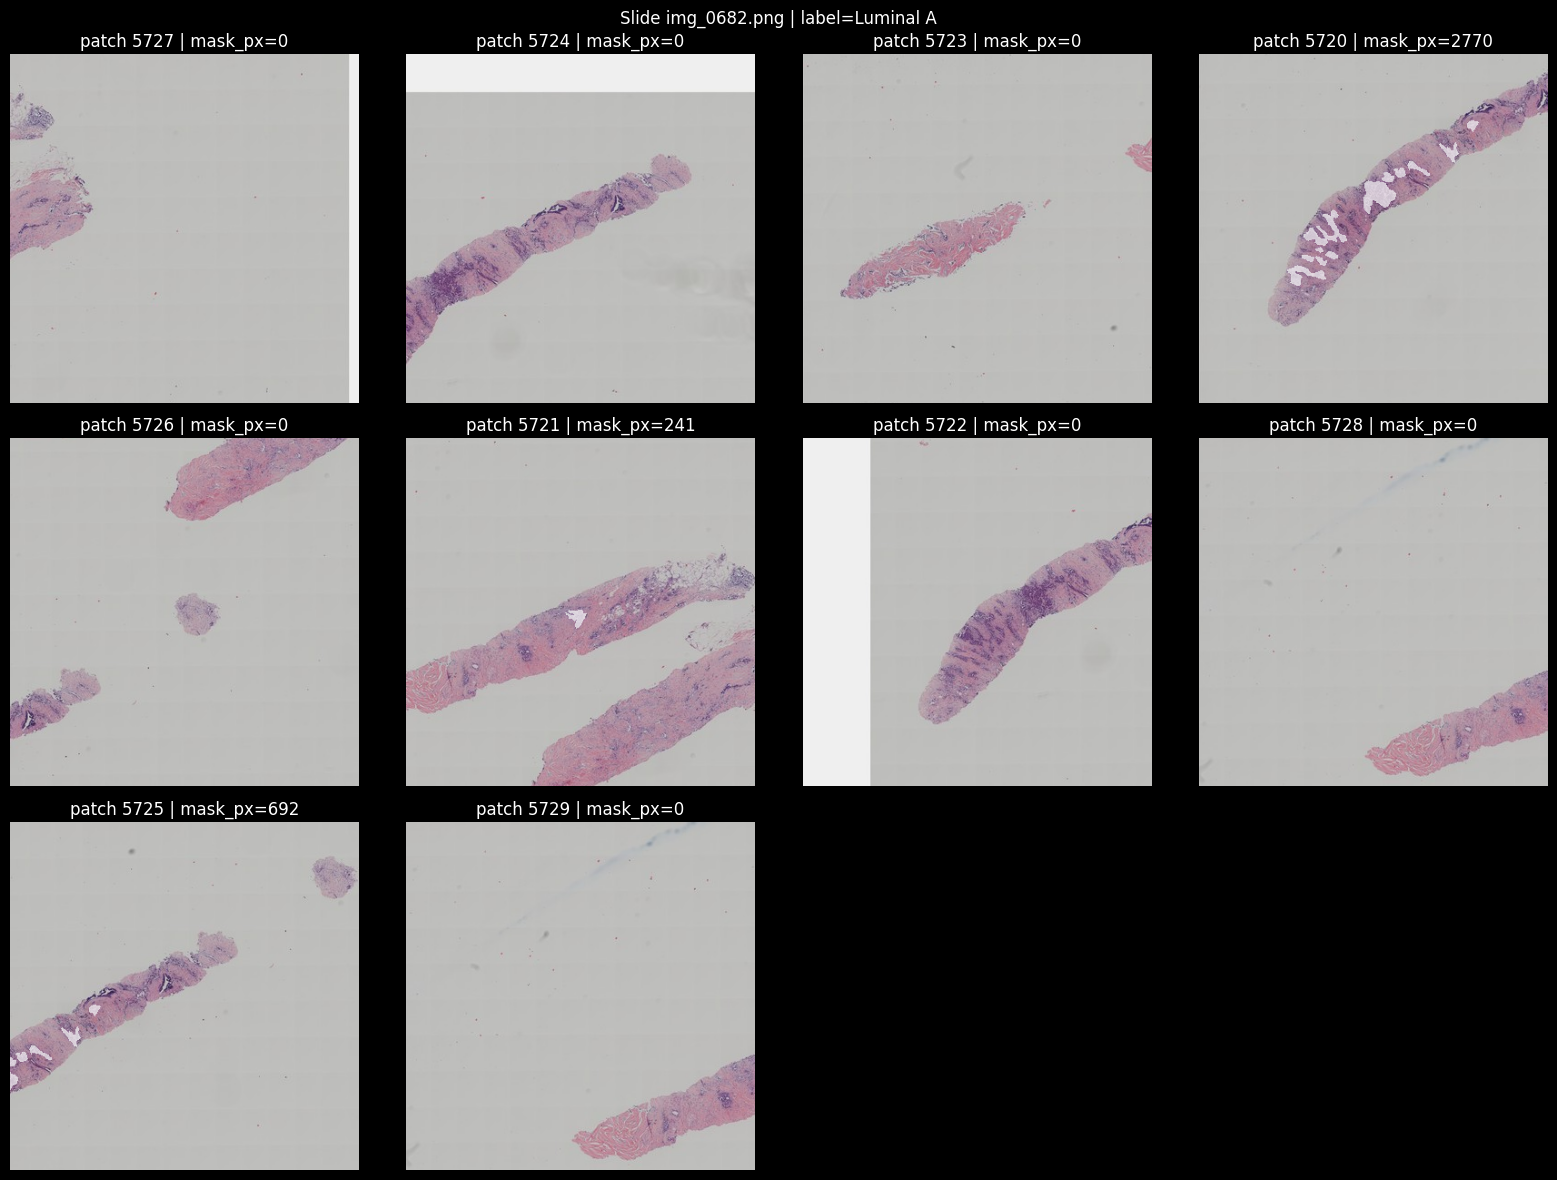

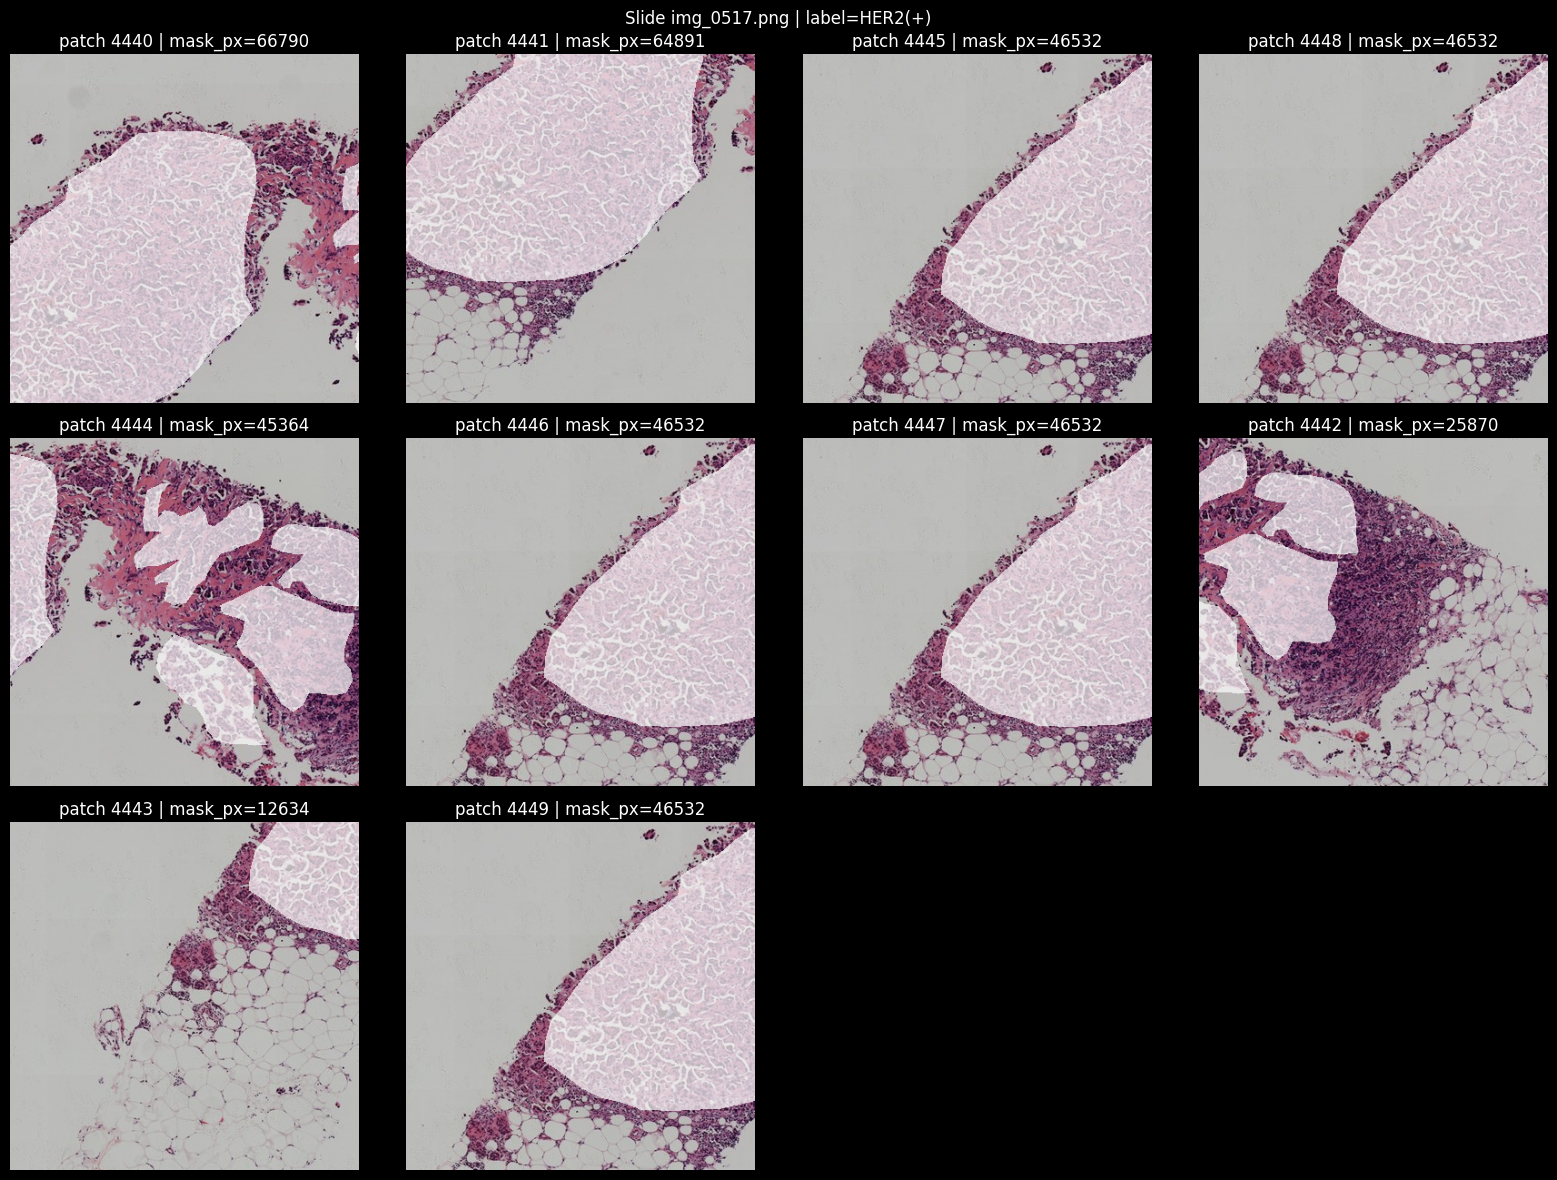

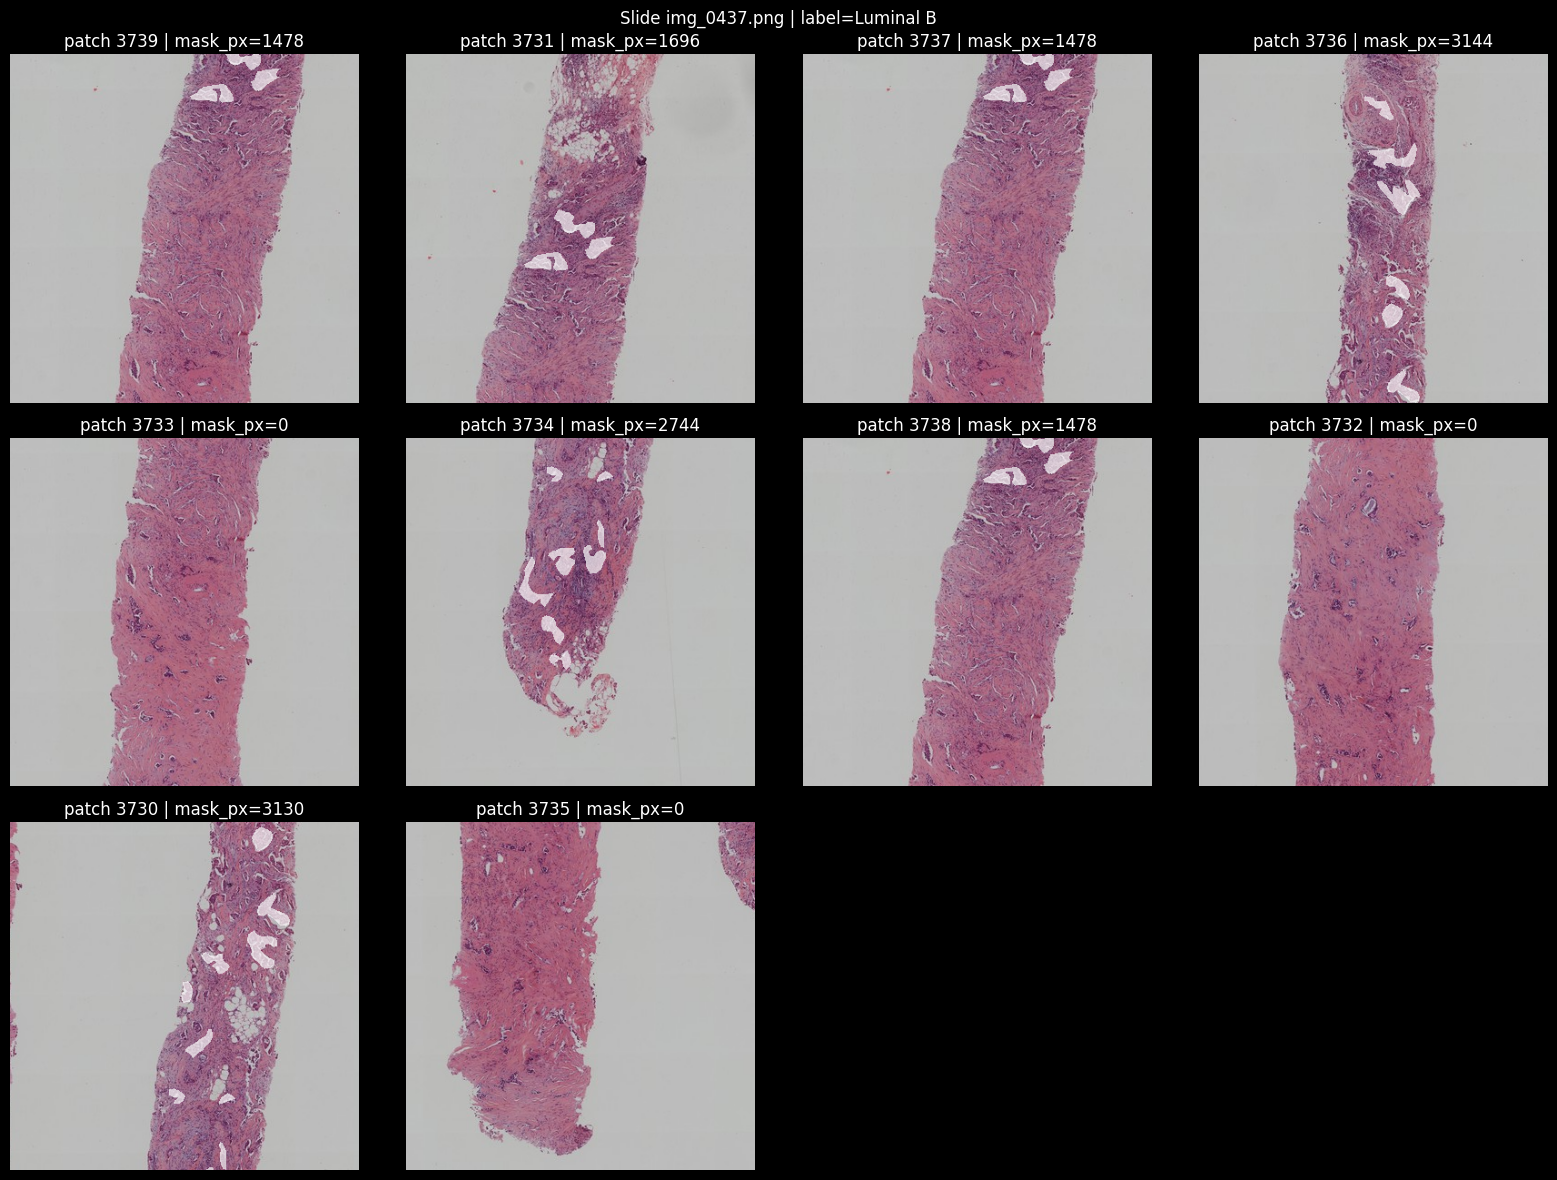

In [7]:
def show_slide_patches(slide_idx, k=12):
    start, end = slide_to_patchidx[slide_idx]
    idxs = np.arange(start, end)
    if len(idxs) == 0:
        print("No patches for slide", slide_idx)
        return
    choose = np.random.choice(idxs, size=min(k, len(idxs)), replace=False)

    n = len(choose)
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4*cols, 4*rows))
    for i, pidx in enumerate(choose):
        img = X[pidx]
        msk = M[pidx, :, :, 0]

        # overlay mask (white) on image
        overlay = img.copy()
        overlay[msk > 0] = np.clip(overlay[msk > 0] * 0.3 + 255 * 0.7, 0, 255).astype(np.uint8)

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(overlay)
        ax.set_title(f"patch {pidx} | mask_px={int((msk>0).sum())}")
        ax.axis("off")

    plt.suptitle(f"Slide {df['sample_index'].iloc[slide_idx]} | label={ID2CLASS[int(y[slide_idx])]}")
    plt.tight_layout()
    plt.show()

# Try a few random slides
for _ in range(3):
    s = np.random.randint(0, len(slide_to_patchidx))
    show_slide_patches(s, k=N_PATCHES)


In [8]:
def patch_stats(num_random=5000):
    total = total_patches
    idxs = np.random.choice(np.arange(total), size=min(num_random, total), replace=False)

    mask_px = []
    tissue_frac = []

    for p in idxs:
        img = X[p].astype(np.float32)
        msk = M[p, :, :, 0] > 0

        mask_px.append(msk.sum())

        gray = img.mean(axis=2)
        tissue = (gray < 240)  # same idea as tissue detector
        tissue_frac.append(tissue.mean())

    mask_px = np.array(mask_px)
    tissue_frac = np.array(tissue_frac)

    print("Mask pixels per patch:")
    print("  % with any mask:", (mask_px > 0).mean())
    print("  median:", np.median(mask_px), "p95:", np.percentile(mask_px, 95))

    print("Tissue fraction per patch:")
    print("  median:", np.median(tissue_frac), "p10:", np.percentile(tissue_frac, 10))

patch_stats()


Mask pixels per patch:
  % with any mask: 0.7362
  median: 2150.5 p95: 21731.15
Tissue fraction per patch:
  median: 1.0 p10: 1.0
